# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras
from src.modeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7814 entries, 8 to 10779
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   CashAndCashEquivalents                7814 non-null   float64       
 1   CurrentDebt                           7814 non-null   float64       
 2   LongTermDebt                          7814 non-null   float64       
 3   TotalDebt                             7814 non-null   float64       
 4   StockholdersEquity                    7814 non-null   float64       
 5   TotalAssets                           7814 non-null   float64       
 6   CurrentAssets                         7814 non-null   float64       
 7   CurrentLiabilities                    7814 non-null   float64       
 8   TotalNoncurrentLiabilities            7814 non-null   float64       
 9   TotalLiabilities                      7814 non-null   float64       
 10  Oper

## Feature Engineering

In [4]:
# Sección reservada para crear variables en la fase de modelado. 

## Modelo de ensamblado de árboles RandomForest

In [5]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Incluir las variables que tengan baja importancia para reducir el ruido (ej: importance < 0.01)
variables_no_significativas = [

]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Posibles labels:
    # 1) Ratios de valuación
    'BookToMarket', 
    'EarningsYield',
    'EbitdaYield',    
    # 2) Variables de tamaño (si se usan como label, quitar predictores RelativeAssets y RelativeRevenue para evitar Data Leakage)
    'MarketCap_Log1p',
    'EnterpriseValue_Log1p',

    # Precios (no usar como labels, no tiene sentido predecir precios crudos teniendo multiples tickers)
    'Open',
    'Close',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource',
    'AverageDailyVolume_Lag1'
    ]

# Se define la variable objetivo y las variables predictoras
label = 'EbitdaYield'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.3672


In [6]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.2505 ± 0.1196


In [7]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
31,cat__Industry,0.206246
1,num__OperatingMargins,0.137406
6,num__NetDebtToEbitda,0.119566
27,num__CapExToRevenue_Log1p,0.088276
3,num__ReturnOnAssets,0.078311
18,num__TotalRevenue_TTM_Acceleration,0.043120
8,num__TotalRevenue_TTM_YoY,0.040554
7,num__FcfToEbitda,0.038983
10,num__EBITDA_TTM_YoY,0.034848
14,num__CapitalExpenditure_TTM_YoY,0.029562


In [8]:
feature_importance_df.tail(6)

,feature,importance
24,num__MarketCovariance_Lag1,0.002026
29,num__QuarterlyVariance_Lag1_Log1p,0.002015
23,num__QuarterlyReturn_Lag1,0.001870
22,num__AverageDailyVolume_Lag1_Acceleration,0.001699
13,num__FreeCashFlow_TTM_QoQ,0.001607
17,num__AverageDailyVolume_Lag1_QoQ,0.000325


In [9]:
# Visualizar distribución de features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,7814.0,15.136038,20.436722,0.000000e+00,0.000000,7.000000,24.000000,69.000000
OperatingMargins,7814.0,0.141973,0.120307,-3.498320e-01,0.063685,0.124597,0.200976,0.615838
ProfitMargins,7814.0,0.094906,0.112806,-2.982820e-01,0.033517,0.082064,0.144027,0.480588
ReturnOnAssets,7814.0,0.066589,0.071552,-1.855690e-01,0.029056,0.058255,0.099927,0.314485
ReturnOnEquity,7814.0,0.199416,0.267777,-5.762220e-01,0.077176,0.159182,0.292364,0.941371
CurrentRatio,7814.0,1.642115,0.926107,1.314860e-01,1.046371,1.393794,1.982452,4.793313
NetDebtToEbitda,7814.0,3.097643,5.704728,-1.217148e+01,0.631678,2.346451,4.869075,17.612231
FcfToEbitda,7814.0,0.701858,0.904305,-1.534732e+00,0.389627,0.710906,1.029487,2.949749
TotalRevenue_TTM_YoY,7814.0,0.086686,0.169088,-4.616255e-01,-0.006124,0.064415,0.143781,0.593825
TotalRevenue_TTM_QoQ,7814.0,0.018179,0.044423,-1.202386e-01,-0.003355,0.014880,0.034904,0.150208


## Aplicación del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [10]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train, X_test, y_train, y_test = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Se calculan los residuos y el Cluster: PositiveBias / NegativeBias según el signo de los residuos
resultados_agrupados = procesar_resultados_prediccion(
    y_test=y_test, 
    y_pred=y_pred, 
    tickers=tickers_test
)

# Visualizar los resultados de la predicción
visualizar_resultados_predicciones(resultados_agrupados)


Estadísticas por cluster (a nivel de Ticker):
Sesgos positivos: 181 tickers, residuo medio global: 0.0256
Sesgos negativos: 241 tickers, residuo medio global: -0.0282


In [11]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker  Predicted  Observed  Residuals      Cluster  PercentError
  SNEX   0.350647  0.089858   0.260789 PositiveBias    290.223344
  SMCI   0.281697  0.050638   0.231059 PositiveBias    456.295111
  SATS  -0.120597 -0.319040   0.198443 PositiveBias    -62.200144
   STX   0.197208  0.016711   0.180497 PositiveBias   1080.109024
   FMC  -0.096682 -0.275888   0.179206 PositiveBias    -64.956089


In [12]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,AverageDailyVolume_Lag1_Acceleration,QuarterlyReturn_Lag1,MarketCovariance_Lag1,RelativeAssets,RelativeRevenue,CapExToRevenue_Log1p,DebtToEquity_Log1p,QuarterlyVariance_Lag1_Log1p,MarketCap_Log1p,EnterpriseValue_Log1p
0,SNEX,0.350647,0.089858,0.260789,PositiveBias,290.223344,2122.600,564.800,21048.700,21832.800,...,-1.135629,0.400854,-0.003080,0.002728,0.005441,0.000479,2.206990,0.047712,9.035291,10.243680
1,SMCI,0.281697,0.050638,0.231059,PositiveBias,456.295111,1290.324,2095.069,6678.032,8805.804,...,0.177339,-0.074019,0.000280,0.001193,0.002322,0.004632,0.771226,0.005205,10.215484,10.458478
2,SATS,-0.120597,-0.319040,0.198443,PositiveBias,-62.200144,1883.074,7321.269,18658.602,30117.140,...,0.051379,0.234085,0.019508,0.002188,0.001034,0.096611,1.828320,0.097904,10.112257,10.875729
3,STX,0.197208,0.016711,0.180497,PositiveBias,1080.109024,1146.000,398.000,3465.000,4178.000,...,-0.707969,0.450338,0.006389,0.000452,0.000759,0.041367,1.571845,0.043623,12.158927,12.174694
4,FMC,-0.096682,-0.275888,0.179206,PositiveBias,-64.956089,390.900,1763.000,2770.600,4533.600,...,-0.486194,0.012107,-0.008609,0.000479,0.000237,0.023395,1.249362,0.097904,7.444436,8.674713


## Explicabilidad del Modelo (SHAP)

In [13]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'GOOG'

--- Explicación de la predicción para: GOOG ---


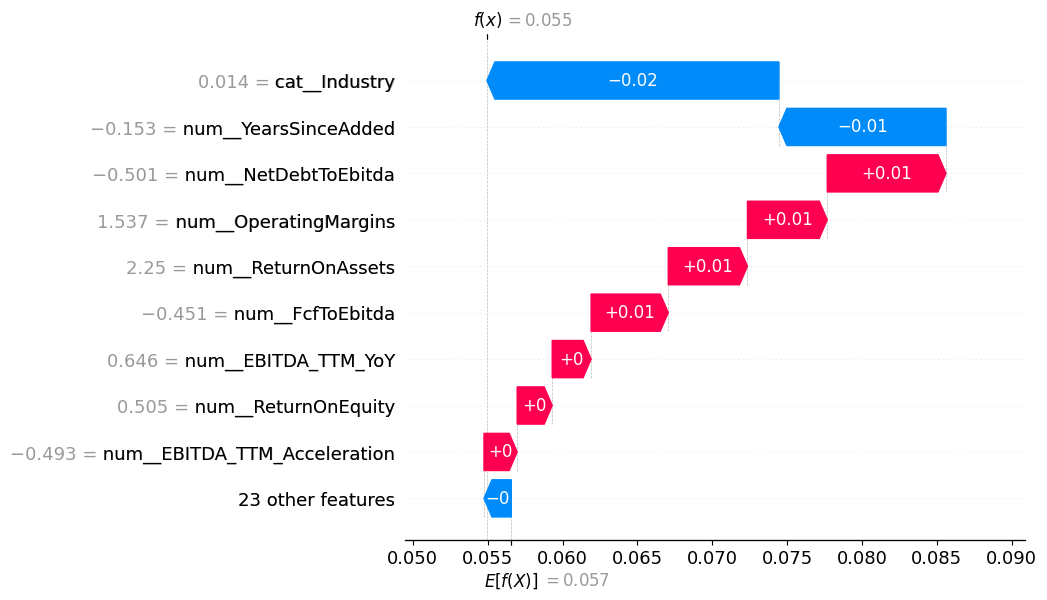

In [14]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [15]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)